<a href="https://colab.research.google.com/github/preranna-1/mindcall-health-intent-classifier/blob/main/Final_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install sentence-transformers -q
!pip install shap lime datasets scikit-learn matplotlib pandas -q
!pip install -q transformers datasets evaluate accelerate
!pip install -U datasets -q

#!pip install torch torchvision torchaudio --upgrade

In [ ]:
import torch
print(torch.__version__)
print(torch.version.cuda)


2.13.0+cu130
13.0


In [ ]:
pip uninstall torchaudio torchvision

In [ ]:
pip install torch==2.13.0

In [ ]:
pip install transformers sentence-transformers datasets evaluate


In [ ]:
import torch
print(torch.__version__, torch.version.cuda)
from transformers import AutoModel
from sentence_transformers import SentenceTransformer
print("Environment is clean and working!")


2.13.0+cu130 13.0
Environment is clean and working!


In [ ]:
import pandas as pd
import numpy as np
import re
import torch

import matplotlib.pyplot as plt


from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import silhouette_score, adjusted_rand_score

from sklearn.preprocessing import LabelEncoder

from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
import evaluate


from datasets import load_dataset
import shap
from lime.lime_text import LimeTextExplainer

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


Using device: cuda


In [ ]:
# Load the datasets
train = pd.read_parquet("/content/drive/MyDrive/datamine/train-00000-of-00001.parquet")
validation = pd.read_parquet("/content/drive/MyDrive/datamine/validation-00000-of-00001.parquet")
test = pd.read_parquet("/content/drive/MyDrive/datamine/test-00000-of-00001.parquet")

# Display dataset sizes
print("Train Shape:", train.shape)
print("Validation Shape:", validation.shape)
print("Test Shape:", test.shape)

Train Shape: (3824, 8)
Validation Shape: (510, 8)
Test Shape: (765, 8)


In [ ]:
train.head()

,patient_query,type,thinking,num_days,function,patient_id,assistant_response,text
0,I wonder if my inconsistent sleep is affecting...,implicit,User hints at connection between sleep and exe...,7.0,get_exercise_session_data,P_2578,<think>\nUser hints at connection between slee...,You are a helpful mental health assistant. Whe...
1,How’s my metabolism been since I started meds ...,explicit,The user explicitly asks about metabolism tied...,7.0,get_bmr_data,P_621,<think>\nThe user explicitly asks about metabo...,You are a helpful mental health assistant. Whe...
2,Can you check my blood glucose data for the la...,explicit,The user explicitly requests glucose data for ...,20.0,get_blood_glucose_data,P_3493,<think>\nThe user explicitly requests glucose ...,You are a helpful mental health assistant. Whe...
3,I solve problems faster in a chilly room—does ...,behavioral,Mild cold may enhance focus. Let's correlate y...,15.0,get_body_temp_data,P_1368,<think>\nMild cold may enhance focus. Let's co...,You are a helpful mental health assistant. Whe...
4,I took up daily runs two weeks ago. How far ha...,behavioral,"The user mentions a new habit of daily runs, i...",14.0,get_distance_data,P_881,<think>\nThe user mentions a new habit of dail...,You are a helpful mental health assistant. Whe...


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3824 entries, 0 to 3823
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   patient_query       3824 non-null   object 
 1   type                3824 non-null   object 
 2   thinking            3824 non-null   object 
 3   num_days            3799 non-null   float64
 4   function            3824 non-null   object 
 5   patient_id          3824 non-null   object 
 6   assistant_response  3824 non-null   object 
 7   text                3824 non-null   object 
dtypes: float64(1), object(7)
memory usage: 239.1+ KB


*The training dataset contains 3,824 instances and 8 features. Seven features are categorical/textual (object type), while one feature (num_days) is numerical (float64). All columns are complete except num_days, which contains 25 missing values that will be handled during preprocessing.*

---

*EDA finding: The dataset consists of 3,824 training samples, 510 validation samples, and 765 test samples, with 8 features in each split. Dataset profiling was performed to examine the structure, data types, missing values, and duplicate records. The analysis showed that seven features are textual/categorical (object) and one feature (num_days) is numerical (float64). The num_days column contains 25 missing values, while all other features are complete. No duplicate records were found in the training dataset.*


---



In [ ]:
# Check missing values
print("Missing Values:")
print(train.isnull().sum())

# Check duplicate rows
print("\nDuplicate Rows:", train.duplicated().sum())

Missing Values:
patient_query          0
type                   0
thinking               0
num_days              25
function               0
patient_id             0
assistant_response     0
text                   0
dtype: int64

Duplicate Rows: 0


In [ ]:
print(train["function"].value_counts())

function
get_power_data                  208
get_bmr_data                    204
get_speed_data                  204
get_exercise_heart_rate_data    203
get_oxygen_saturation_data      202
get_steps_data                  202
get_height_data                 193
get_distance_data               192
get_blood_glucose_data          190
get_nutrition_data              189
get_blood_pressure_data         189
get_calories_burned_data        188
get_body_fat_data               186
get_heart_rate_data             186
get_stress_data                 183
get_exercise_session_data       182
get_body_temp_data              182
get_vo2max_data                 182
get_sleep_data                  181
get_weight_data                 178
Name: count, dtype: int64


Input X is: patient_query and Target Variable is : function. Why function and not type?

The type column has only three categories (implicit, explicit, behavioral), while function contains the actual action that should be performed. Predicting the function is a richer and more practical classification task, and your dataset appears to be designed for it.

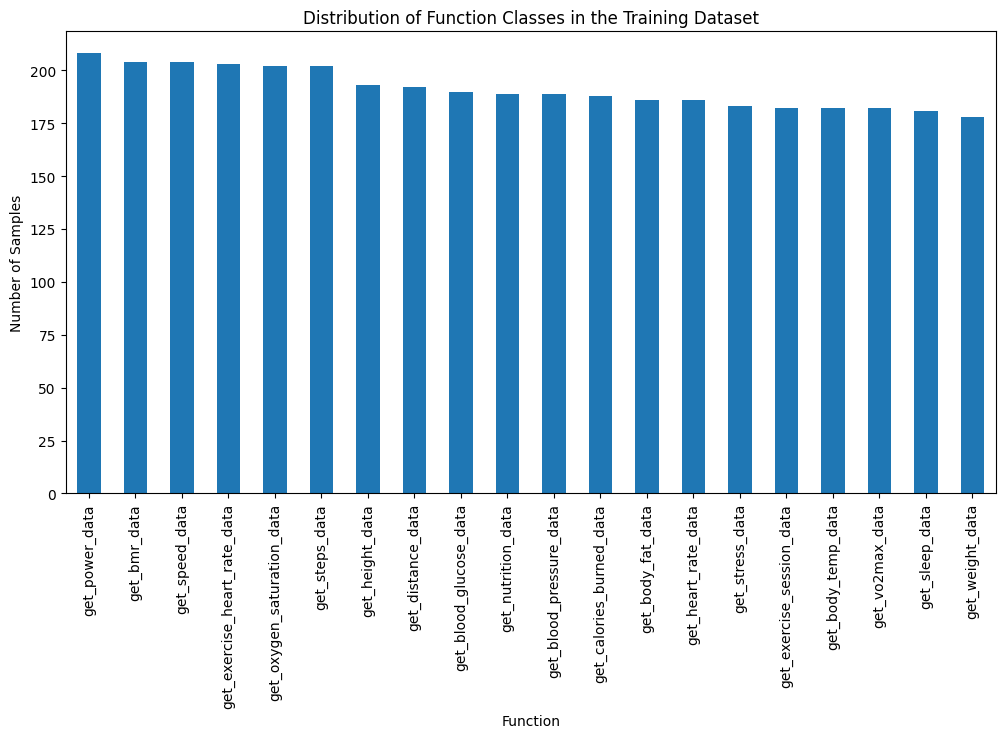

In [ ]:
plt.figure(figsize=(12, 6))

train["function"].value_counts().plot(kind="bar")

plt.title("Distribution of Function Classes in the Training Dataset")
plt.xlabel("Function")
plt.ylabel("Number of Samples")
plt.xticks(rotation=90)

plt.show()

The bar chart shows the distribution of the target classes (function) in your training dataset.

Each bar represents one function (class), such as:
get_power_data
get_bmr_data
get_steps_data
get_sleep_data
etc.
The height of each bar represents the number of training samples belonging to that function.

For example:

get_power_data has 208 samples.
get_sleep_data has 181 samples.
get_weight_data has 178 samples.

The dataset is relatively balanced. ✅
Each class contains approximately 178–208 samples.
This is good because:

Every class has a similar number of examples.
The models won't be heavily biased toward one class.
Accuracy and F1-score will be more meaningful.

In [ ]:
# Fill missing values in num_days using the median from the training set
median_days = train["num_days"].median()

train["num_days"] = train["num_days"].fillna(median_days)
validation["num_days"] = validation["num_days"].fillna(median_days)
test["num_days"] = test["num_days"].fillna(median_days)

In [ ]:
def clean_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove punctuation
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [ ]:
train["clean_query"] = train["patient_query"].apply(clean_text)
validation["clean_query"] = validation["patient_query"].apply(clean_text)
test["clean_query"] = test["patient_query"].apply(clean_text)

train[["patient_query", "clean_query"]].head()

,patient_query,clean_query
0,I wonder if my inconsistent sleep is affecting...,i wonder if my inconsistent sleep is affecting...
1,How’s my metabolism been since I started meds ...,hows my metabolism been since i started meds l...
2,Can you check my blood glucose data for the la...,can you check my blood glucose data for the la...
3,I solve problems faster in a chilly room—does ...,i solve problems faster in a chilly roomdoes m...
4,I took up daily runs two weeks ago. How far ha...,i took up daily runs two weeks ago how far hav...


Compared before and after cleaning / Data Preprocessing: Data Preprocessing:
The preprocessing stage involved handling missing values and cleaning the textual data. Missing values in the num_days feature were replaced using the median value computed from the training dataset. The patient_query text was converted to lowercase, URLs and punctuation were removed, and extra whitespace was eliminated to produce standardized text for TF-IDF feature extraction.

---



In [ ]:
tfidf = TfidfVectorizer(max_features=5000)

# Convert text into TF-IDF features
X_train = tfidf.fit_transform(train["clean_query"])

X_validation = tfidf.transform(validation["clean_query"])

X_test = tfidf.transform(test["clean_query"])

# Labels
y_train = train["function"]
y_validation = validation["function"]
y_test = test["function"]

print("Training TF-IDF Shape:", X_train.shape)
print("Validation TF-IDF Shape:", X_validation.shape)
print("Test TF-IDF Shape:", X_test.shape)

Training TF-IDF Shape: (3824, 3596)
Validation TF-IDF Shape: (510, 3596)
Test TF-IDF Shape: (765, 3596)


TF-IDF Feature Extraction:

1.   List item
2.   List item

The cleaned patient queries were transformed into numerical feature vectors using the TF-IDF vectorization technique. Although the maximum vocabulary size was set to 5,000, the training dataset contained 3,596 unique informative terms, resulting in a TF-IDF feature matrix of size 3824 × 3596 for the training set. The same feature space was applied to the validation and test datasets to ensure consistency.


In [ ]:


# Create Logistic Regression model
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
y_pred_lr = lr_model.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.7856209150326797

Classification Report:

                              precision    recall  f1-score   support

      get_blood_glucose_data       0.86      0.76      0.81        33
     get_blood_pressure_data       0.88      0.82      0.85        34
                get_bmr_data       0.91      0.84      0.87        37
           get_body_fat_data       0.89      0.72      0.79        43
          get_body_temp_data       0.95      0.93      0.94        43
    get_calories_burned_data       0.49      0.51      0.50        43
           get_distance_data       0.84      0.74      0.79        43
get_exercise_heart_rate_data       0.88      0.90      0.89        31
   get_exercise_session_data       0.56      0.53      0.54        36
         get_heart_rate_data       0.95      0.90      0.93        41
             get_height_data       0.88      0.82      0.85        34
          get_nutrition_data       0.71      0.83      0.77        42
  get_oxygen_saturation_data       

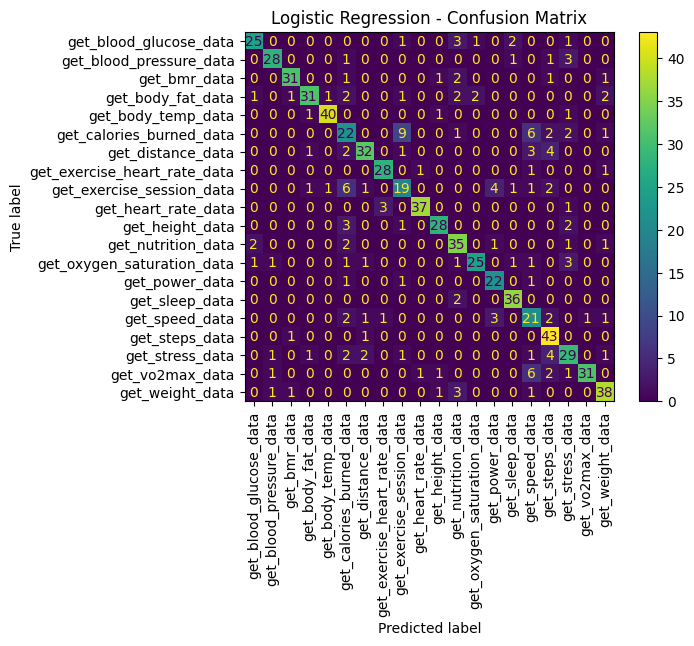

In [ ]:
ConfusionMatrixDisplay.from_estimator(
    lr_model,
    X_test,
    y_test,
    xticks_rotation=90
)

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

Why are we evaluating on the test set?
Training set: Used to learn the model parameters.
Validation set: Typically used for tuning hyperparameters (e.g., choosing the best C value or model settings).
Test set: Used once at the end to measure how well the final model generalizes to unseen data.

For a baseline experiment, training on the training set and reporting results on the test set is appropriate.

In [ ]:
svm_model = LinearSVC(random_state=42)

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

In [ ]:

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))

Accuracy: 0.7986928104575164

Classification Report:

                              precision    recall  f1-score   support

      get_blood_glucose_data       0.90      0.79      0.84        33
     get_blood_pressure_data       0.85      0.85      0.85        34
                get_bmr_data       0.94      0.84      0.89        37
           get_body_fat_data       0.81      0.70      0.75        43
          get_body_temp_data       0.91      0.98      0.94        43
    get_calories_burned_data       0.57      0.60      0.58        43
           get_distance_data       0.82      0.77      0.80        43
get_exercise_heart_rate_data       0.80      0.90      0.85        31
   get_exercise_session_data       0.44      0.39      0.41        36
         get_heart_rate_data       0.97      0.85      0.91        41
             get_height_data       0.91      0.91      0.91        34
          get_nutrition_data       0.79      0.88      0.83        42
  get_oxygen_saturation_data       

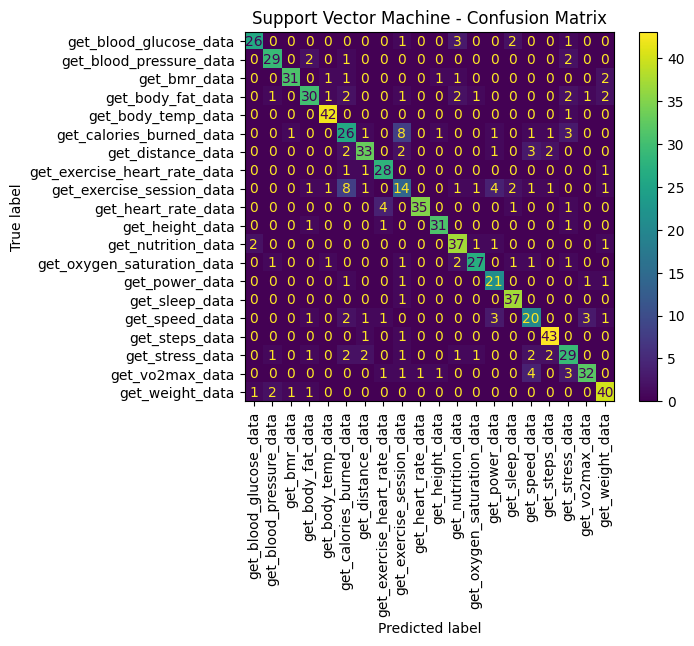

In [ ]:


ConfusionMatrixDisplay.from_estimator(
    svm_model,
    X_test,
    y_test,
    xticks_rotation=90
)

plt.title("Support Vector Machine - Confusion Matrix")
plt.show()

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7725490196078432

Classification Report:

                              precision    recall  f1-score   support

      get_blood_glucose_data       0.83      0.76      0.79        33
     get_blood_pressure_data       0.87      0.79      0.83        34
                get_bmr_data       0.88      0.78      0.83        37
           get_body_fat_data       0.84      0.74      0.79        43
          get_body_temp_data       0.95      0.88      0.92        43
    get_calories_burned_data       0.47      0.53      0.50        43
           get_distance_data       0.78      0.72      0.75        43
get_exercise_heart_rate_data       0.87      0.87      0.87        31
   get_exercise_session_data       0.62      0.69      0.66        36
         get_heart_rate_data       0.88      0.88      0.88        41
             get_height_data       0.88      0.82      0.85        34
          get_nutrition_data       0.76      0.67      0.71        42
  get_oxygen_saturation_data       

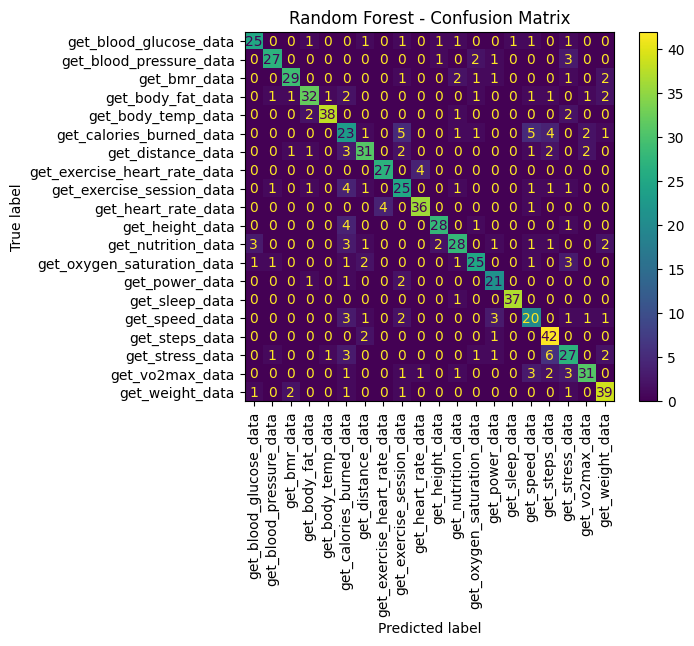

In [ ]:
ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_test,
    y_test,
    xticks_rotation=90
)

plt.title("Random Forest - Confusion Matrix")
plt.show()

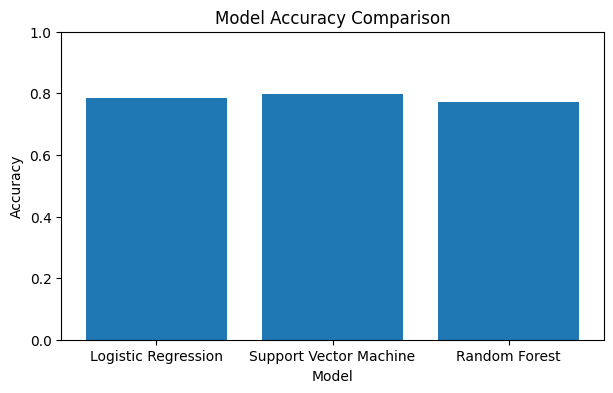

In [ ]:

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Support Vector Machine",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_rf)
    ]
})

results


plt.figure(figsize=(7,4))
plt.bar(results["Model"], results["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

SVM achieved the highest accuracy (79.87%), making it the best-performing baseline model.
Logistic Regression performed almost as well, showing that linear models are effective for TF-IDF text features.
Random Forest achieved the lowest accuracy. This is common in text classification because tree-based models generally do not perform as well as linear models on high-dimensional sparse TF-IDF vectors.

In [ ]:


def evaluate_model(y_true, y_pred):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average='weighted'
    )

    accuracy = accuracy_score(y_true, y_pred)

    return accuracy, precision, recall, f1


lr_metrics = evaluate_model(y_test, y_pred_lr)
svm_metrics = evaluate_model(y_test, y_pred_svm)
rf_metrics = evaluate_model(y_test, y_pred_rf)

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Support Vector Machine",
        "Random Forest"
    ],
    "Accuracy": [lr_metrics[0], svm_metrics[0], rf_metrics[0]],
    "Precision": [lr_metrics[1], svm_metrics[1], rf_metrics[1]],
    "Recall": [lr_metrics[2], svm_metrics[2], rf_metrics[2]],
    "F1-score": [lr_metrics[3], svm_metrics[3], rf_metrics[3]]
})

results

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.785621,0.799055,0.785621,0.787730
1,Support Vector Machine,0.798693,0.801224,0.798693,0.797668
2,Random Forest,0.772549,0.781195,0.772549,0.774405


In [ ]:

label_encoder = LabelEncoder()
label_encoder.fit(train["function"])

train["label"] = label_encoder.transform(train["function"])
validation["label"] = label_encoder.transform(validation["function"])
test["label"] = label_encoder.transform(test["function"])

num_labels = len(label_encoder.classes_)
print("Number of classes:", num_labels)
print(dict(enumerate(label_encoder.classes_)))

Number of classes: 20
{0: 'get_blood_glucose_data', 1: 'get_blood_pressure_data', 2: 'get_bmr_data', 3: 'get_body_fat_data', 4: 'get_body_temp_data', 5: 'get_calories_burned_data', 6: 'get_distance_data', 7: 'get_exercise_heart_rate_data', 8: 'get_exercise_session_data', 9: 'get_heart_rate_data', 10: 'get_height_data', 11: 'get_nutrition_data', 12: 'get_oxygen_saturation_data', 13: 'get_power_data', 14: 'get_sleep_data', 15: 'get_speed_data', 16: 'get_steps_data', 17: 'get_stress_data', 18: 'get_vo2max_data', 19: 'get_weight_data'}


In [ ]:

MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_batch(texts):
    return tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=64,
        return_tensors="pt"
    )

In [ ]:
from datasets import Dataset


def to_hf_dataset(df):
    ds = Dataset.from_pandas(df[["patient_query", "label"]].reset_index(drop=True))
    ds = ds.map(lambda batch: tokenizer(batch["patient_query"], truncation=True, max_length=64, padding="max_length"), batched=True)
    ds = ds.remove_columns(["patient_query"])
    ds.set_format("torch")
    return ds

train_ds = to_hf_dataset(train)
val_ds = to_hf_dataset(validation)
test_ds = to_hf_dataset(test)

print(train_ds)

Map:   0%|          | 0/3824 [00:00<?, ? examples/s]

Map:   0%|          | 0/510 [00:00<?, ? examples/s]

Map:   0%|          | 0/765 [00:00<?, ? examples/s]

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 3824
})


In [ ]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
import evaluate

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels
).to(device)

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=preds, references=labels)["accuracy"]
    f1 = f1_metric.compute(predictions=preds, references=labels, average="weighted")["f1"]
    return {"accuracy": acc, "f1": f1}

training_args = TrainingArguments(
    output_dir="./distilbert-mindcall",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=4,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=50,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics
)

trainer.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.868898,1.343867,0.764706,0.759892
2,0.959638,0.782672,0.829412,0.828370
3,0.612846,0.620668,0.860784,0.860817
4,0.483682,0.578891,0.868627,0.868402


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=956, training_loss=1.1320377658101803, metrics={'train_runtime': 188.0433, 'train_samples_per_second': 81.343, 'train_steps_per_second': 5.084, 'total_flos': 253358969487360.0, 'train_loss': 1.1320377658101803, 'epoch': 4.0})

In [ ]:
!pip install -U datasets -q

In [ ]:
!pip uninstall -y torchvision -q

Accuracy: 0.8366013071895425

Classification Report:

                              precision    recall  f1-score   support

      get_blood_glucose_data       0.90      0.85      0.88        33
     get_blood_pressure_data       0.85      0.82      0.84        34
                get_bmr_data       0.91      0.84      0.87        37
           get_body_fat_data       0.85      0.77      0.80        43
          get_body_temp_data       0.91      0.95      0.93        43
    get_calories_burned_data       0.67      0.56      0.61        43
           get_distance_data       0.78      0.81      0.80        43
get_exercise_heart_rate_data       0.83      0.97      0.90        31
   get_exercise_session_data       0.63      0.67      0.65        36
         get_heart_rate_data       0.97      0.88      0.92        41
             get_height_data       0.89      0.97      0.93        34
          get_nutrition_data       0.83      0.90      0.86        42
  get_oxygen_saturation_data       

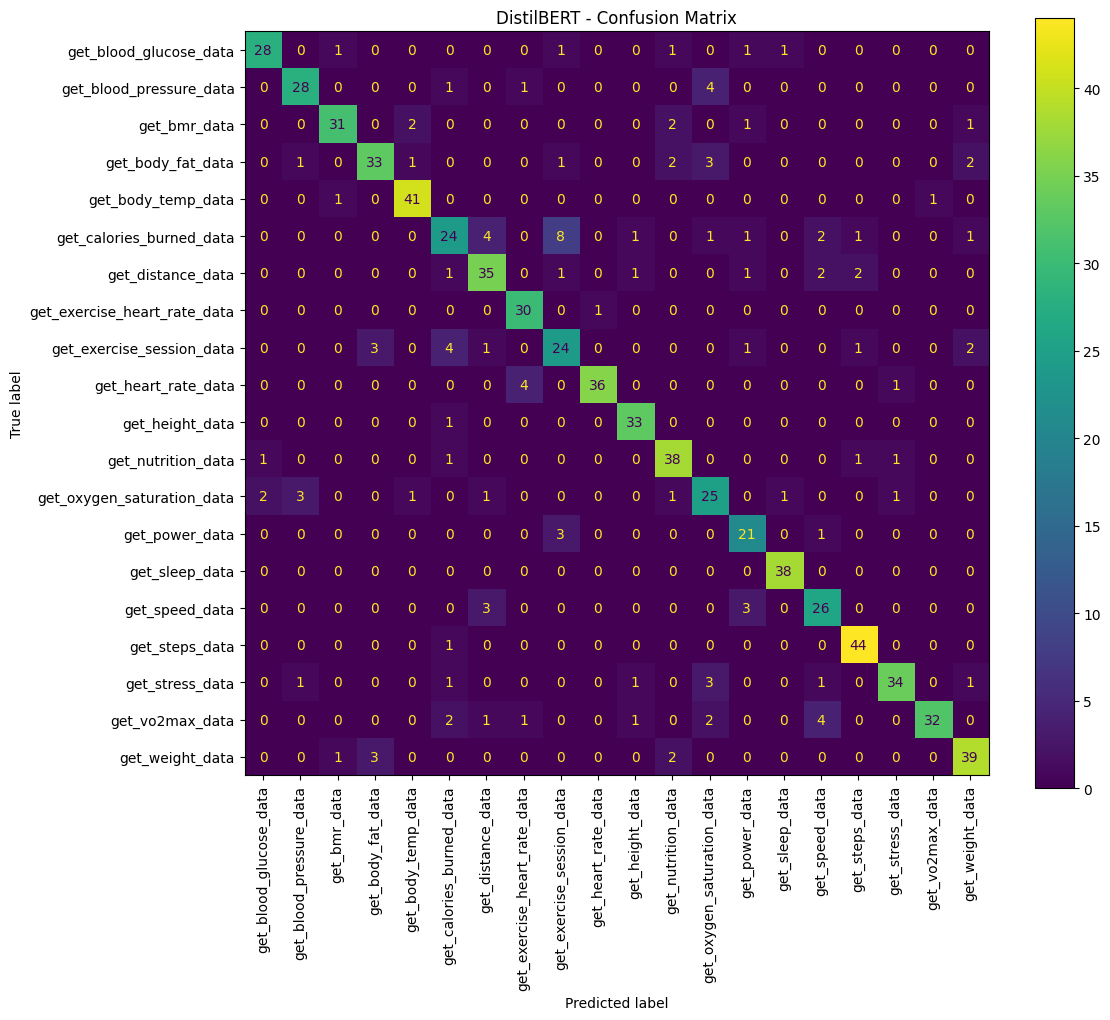

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

test_predictions = trainer.predict(test_ds)
y_pred_bert = np.argmax(test_predictions.predictions, axis=-1)
y_true_bert = test_predictions.label_ids

y_pred_labels = label_encoder.inverse_transform(y_pred_bert)
y_true_labels = label_encoder.inverse_transform(y_true_bert)

print("Accuracy:", accuracy_score(y_true_labels, y_pred_labels))
print("\nClassification Report:\n")
print(classification_report(y_true_labels, y_pred_labels))

fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay.from_predictions(
    y_true_labels, y_pred_labels, xticks_rotation=90, ax=ax
)
plt.title("DistilBERT - Confusion Matrix")
plt.show()

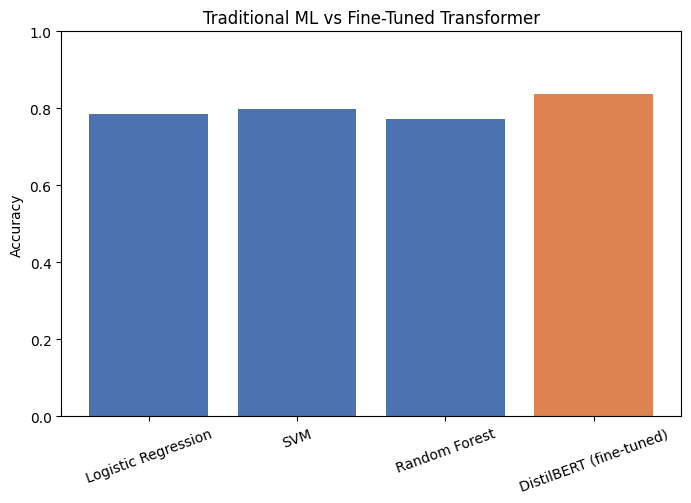

In [ ]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM", "Random Forest", "DistilBERT (fine-tuned)"],
    "Accuracy": [0.785621, 0.798693, 0.772549, accuracy_score(y_true_labels, y_pred_labels)]
})
comparison

plt.figure(figsize=(8,5))
plt.bar(comparison["Model"], comparison["Accuracy"], color=["#4C72B0"]*3 + ["#DD8452"])
plt.title("Traditional ML vs Fine-Tuned Transformer")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.xticks(rotation=20)
plt.show()

In [ ]:
error_df = test.copy()
error_df["true_function"] = y_true_labels
error_df["predicted_function"] = y_pred_labels
error_df["correct"] = error_df["true_function"] == error_df["predicted_function"]

misclassified = error_df[~error_df["correct"]]
print(f"Total misclassified: {len(misclassified)} / {len(error_df)}")

confusion_pairs = (
    misclassified.groupby(["true_function", "predicted_function"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)
print(confusion_pairs.head(15))

misclassified[["patient_query", "true_function", "predicted_function"]].sample(10, random_state=42)

Total misclassified: 125 / 765
                 true_function            predicted_function  count
21    get_calories_burned_data     get_exercise_session_data      8
20    get_calories_burned_data             get_distance_data      4
7      get_blood_pressure_data    get_oxygen_saturation_data      4
41         get_heart_rate_data  get_exercise_heart_rate_data      4
36   get_exercise_session_data      get_calories_burned_data      4
71             get_vo2max_data                get_speed_data      4
16           get_body_fat_data    get_oxygen_saturation_data      3
35   get_exercise_session_data             get_body_fat_data      3
49  get_oxygen_saturation_data       get_blood_pressure_data      3
57              get_speed_data             get_distance_data      3
55              get_power_data     get_exercise_session_data      3
58              get_speed_data                get_power_data      3
63             get_stress_data    get_oxygen_saturation_data      3
73             ge

,patient_query,true_function,predicted_function
116,I’ve stopped late-night snacking for 2 weeks. ...,get_weight_data,get_nutrition_data
260,I started meditation last week. Has it lowered...,get_heart_rate_data,get_exercise_heart_rate_data
227,I started cutting carbs about two weeks ago.,get_body_fat_data,get_nutrition_data
466,Something feels off lately — probably over the...,get_stress_data,get_oxygen_saturation_data
317,"My skin feels tighter around my muscles, but I...",get_body_fat_data,get_oxygen_saturation_data
590,My cheeks look fuller in Zoom calls recently.,get_body_fat_data,get_oxygen_saturation_data
336,"My weight hasn't budged despite walking 10,000...",get_bmr_data,get_weight_data
756,I feel like I’ve been burning rubber during al...,get_calories_burned_data,get_exercise_session_data
603,Am I burning enough calories for my weight los...,get_calories_burned_data,get_weight_data
24,My back has been stiff since I started that ke...,get_exercise_session_data,get_body_fat_data


In [ ]:


model = SentenceTransformer('all-MiniLM-L6-v2')

X_train_emb = model.encode(train["clean_query"].tolist(), show_progress_bar=True)

print("Embedding shape:", X_train_emb.shape)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/120 [00:00<?, ?it/s]

Embedding shape: (3824, 384)


In [ ]:
n_clusters = train["function"].nunique()  # matches number of true classes, for comparison
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_train_emb)

train["kmeans_cluster"] = kmeans_labels


hier = AgglomerativeClustering(n_clusters=n_clusters)
hier_labels = hier.fit_predict(X_train_emb)

train["hier_cluster"] = hier_labels

dbscan = DBSCAN(eps=0.5, min_samples=5, metric='cosine')
dbscan_labels = dbscan.fit_predict(X_train_emb)

train["dbscan_cluster"] = dbscan_labels
print("Number of clusters found:", len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0))
print("Noise points:", (dbscan_labels == -1).sum())

Number of clusters found: 1
Noise points: 64


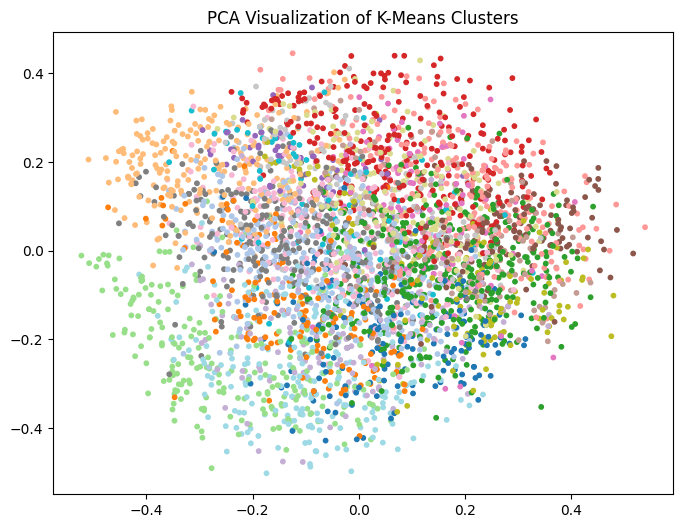

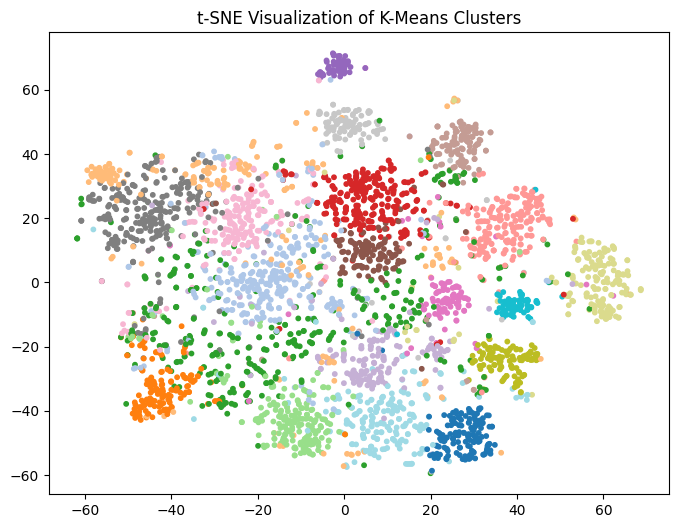

Silhouette Score - KMeans: 0.062447872
Silhouette Score - Hierarchical: 0.036156688
Adjusted Rand Index (KMeans vs true labels): 0.36984388125930256
Adjusted Rand Index (Hierarchical vs true labels): 0.2697663169381825


In [ ]:


# PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_emb)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=kmeans_labels, cmap='tab20', s=10)
plt.title("PCA Visualization of K-Means Clusters")
plt.show()

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_train_emb)

plt.figure(figsize=(8,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=kmeans_labels, cmap='tab20', s=10)
plt.title("t-SNE Visualization of K-Means Clusters")
plt.show()



# Internal quality (doesn't need true labels)
sil_kmeans = silhouette_score(X_train_emb, kmeans_labels)
sil_hier = silhouette_score(X_train_emb, hier_labels)

print("Silhouette Score - KMeans:", sil_kmeans)
print("Silhouette Score - Hierarchical:", sil_hier)

# Comparison against real function labels (just to sanity-check your clusters)
ari_kmeans = adjusted_rand_score(train["function"], kmeans_labels)
ari_hier = adjusted_rand_score(train["function"], hier_labels)

print("Adjusted Rand Index (KMeans vs true labels):", ari_kmeans)
print("Adjusted Rand Index (Hierarchical vs true labels):", ari_hier)

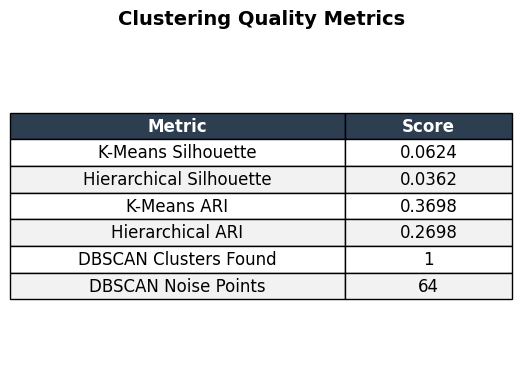

In [ ]:
import matplotlib.pyplot as plt

# Your actual results
metrics_data = [
    ["Metric", "Score"],
    ["K-Means Silhouette", "0.0624"],
    ["Hierarchical Silhouette", "0.0362"],
    ["K-Means ARI", "0.3698"],
    ["Hierarchical ARI", "0.2698"],
    ["DBSCAN Clusters Found", "1"],
    ["DBSCAN Noise Points", "64"]
]

# Create figure and axis
fig, ax = plt.subplots(figsize=(6, 4))
ax.axis('tight')
ax.axis('off')

# Create the table
table = ax.table(
    cellText=metrics_data,
    loc='center',
    cellLoc='center',
    colWidths=[0.6, 0.3]  # Adjust column widths to fit text
)

# Style it
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.6)  # Increases cell padding

# Color the header row (first row)
for i in range(len(metrics_data[0])):  # columns: 0, 1
    cell = table[(0, i)]
    cell.set_facecolor('#2c3e50')  # Dark blue-gray
    cell.set_text_props(color='white', weight='bold')

# Color the value cells (rows 1 to end)
for row_idx in range(1, len(metrics_data)):
    for col_idx in range(len(metrics_data[0])):
        cell = table[(row_idx, col_idx)]
        if row_idx % 2 == 0:  # Alternate row colors for readability
            cell.set_facecolor('#f2f2f2')
        else:
            cell.set_facecolor('#ffffff')

# Add a title above the table
plt.title("Clustering Quality Metrics", fontsize=14, pad=20, weight='bold')

# Save for your presentation
plt.savefig("metrics_box.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# Data Mining Course Project

## Knowledge Discovery and Explainable AI


**Dataset:** MindCall Dataset (Hugging Face)  
https://huggingface.co/datasets/frshafi/mind_call

**Contributor:** Person 4 – Knowledge Discovery & Explainability

### Objectives

This notebook extends the baseline text classification models developed in the project by focusing on knowledge discovery and model interpretability. The implementation includes:

- Data loading and preprocessing
- TF-IDF feature representation
- Logistic Regression classifier (baseline reproduction)
- Association Rule Mining using FP-Growth
- Discovery of frequent itemsets and association rules
- Explainable AI using SHAP
- Local model interpretation using LIME
- Interpretation of discovered knowledge

The objective is to complement the predictive models with interpretable insights that improve transparency and support a better understanding of the model's decisions.

Data Mining Course Project
Person 4: Knowledge Discovery & Explainable AI

Dataset:
MindCall
https://huggingface.co/datasets/frshafi/mind_call

This notebook implements:
1. Dataset loading
2. Text preprocessing
3. TF-IDF feature extraction
4. Logistic Regression baseline
6. SHAP Explainability
7. LIME Explainability

Author: Nawfa Nawar


In [ ]:
explainer = shap.Explainer(
    lr_model,
    X_train,
    feature_names=tfidf.get_feature_names_out()
)

In [ ]:
sample = X_test[:100]

shap_values = explainer(sample)

/tmp/ipykernel_10957/1667333597.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


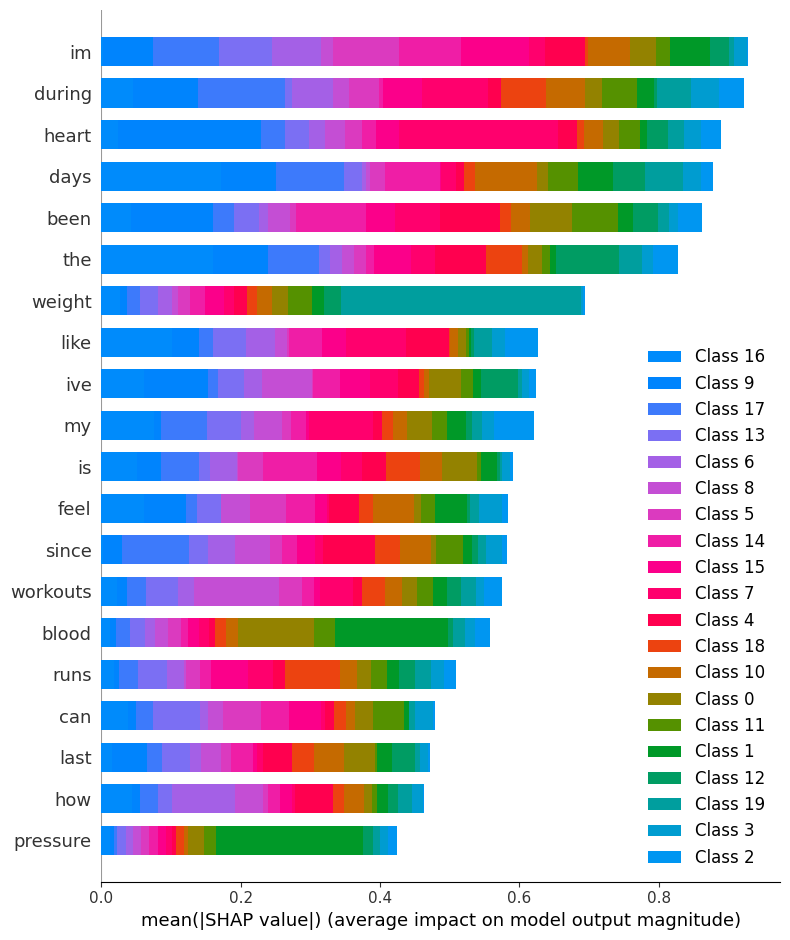

In [ ]:
shap.summary_plot(
    shap_values,
    sample,
    feature_names=tfidf.get_feature_names_out()
)

/tmp/ipykernel_10957/4278411202.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


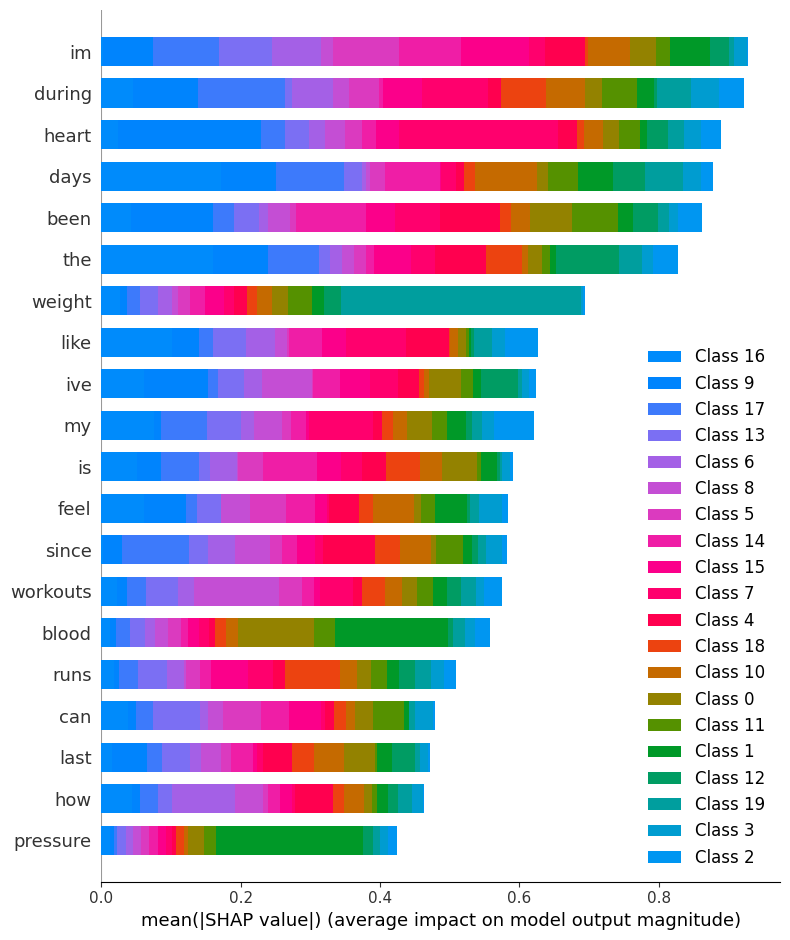

In [ ]:
shap.summary_plot(
    shap_values,
    sample,
    feature_names=tfidf.get_feature_names_out(),
    plot_type="bar"
)

In [ ]:
class_names = sorted(train["function"].unique())

explainer = LimeTextExplainer(
    class_names=class_names
)

In [ ]:
def predict_proba(texts):
    cleaned = [clean_text(t) for t in texts]
    X = tfidf.transform(cleaned)
    return lr_model.predict_proba(X)

In [ ]:
query = test["patient_query"].iloc[0]

print(query)

Since my therapist suggested 'sleep restriction' for insomnia, I'm exhausted but sleeping deeper. Is this the expected pattern?


In [ ]:
exp = explainer.explain_instance(
    query,
    predict_proba,
    num_features=10,
    num_samples=500
)

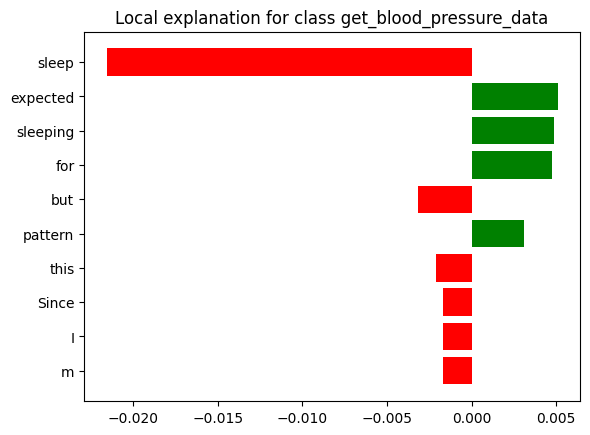

In [ ]:
exp.as_list()

fig = exp.as_pyplot_figure()

plt.show()

In [ ]:
prediction = lr_model.predict(
    tfidf.transform([clean_text(query)])
)

print(prediction)

In [ ]:
predict_proba([query])

array([[0.03246764, 0.02516113, 0.02542389, 0.02336321, 0.02300961,
        0.03565843, 0.0298485 , 0.00825959, 0.03654727, 0.03365418,
        0.0385029 , 0.03713199, 0.03290341, 0.02844173, 0.4725706 ,
        0.03217169, 0.02628651, 0.01448022, 0.0259802 , 0.01813731]])

In [ ]:
for i in [0, 10, 20]:
    query = test["patient_query"].iloc[i]

    exp = explainer.explain_instance(
        query,
        predict_proba,
        num_features=10,
        num_samples=500
    )

    print(f"\nQuery {i}:")
    print(query)
    print(exp.as_list())


Query 0:
Since my therapist suggested 'sleep restriction' for insomnia, I'm exhausted but sleeping deeper. Is this the expected pattern?
[(np.str_('sleep'), -0.022711797243221397), (np.str_('for'), 0.005630547078621588), (np.str_('expected'), 0.005324860816276691), (np.str_('sleeping'), 0.005307067325299291), (np.str_('but'), -0.0037896647113896307), (np.str_('this'), -0.002665170152977932), (np.str_('pattern'), 0.0024684761907198243), (np.str_('m'), -0.0022775583814435216), (np.str_('insomnia'), 0.0016080448339246447), (np.str_('I'), -0.0015801017491912986)]

Query 10:
My heart is a lullaby during knitting but a rock anthem during gaming.
[(np.str_('heart'), -0.018292302875411916), (np.str_('during'), -0.011881225354433742), (np.str_('rock'), 0.006121446777291747), (np.str_('but'), -0.0017710909996605242), (np.str_('is'), 0.0016242053721930653), (np.str_('My'), 0.0009892652742332353), (np.str_('knitting'), -0.0004959443915328901), (np.str_('anthem'), -0.0004063564441700958), (np.str_

In [ ]:
query = test["patient_query"].iloc[20]

print(query)

prediction = lr_model.predict(
    tfidf.transform([clean_text(query)])
)

print("Predicted class:", prediction[0])

Can you check my blood pressure trends for the last 18 days?
Predicted class: get_blood_pressure_data
